# CoverType Forest Classifier

## Import Libraries

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split , cross_val_score ,GridSearchCV,RandomizedSearchCV
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay ,f1_score
from sklearn.preprocessing import StandardScaler ,RobustScaler ,LabelEncoder 
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('GPU Available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.10.0
GPU Available: True


## Load Dataset

In [33]:
df=pd.read_csv("covertype.csv")
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## Understanding Data

In [34]:
df.shape

(581012, 55)

In [35]:
df.columns

Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Elevation', 'Aspect',
       'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type1',
       'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6',
       'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11',
       'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
       'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19',
       'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23',
       'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27',
       'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31',
       'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
       'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40', 'Cover_Type'],
 

In [36]:
df.drop(columns=['Unnamed: 0','Unnamed: 1','Unnamed: 2'], inplace=True)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 52 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area                     581012 non-null  int64
 11  Soil_Type1                          581012 non-null 

In [38]:
df.describe(include="all")

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,0.448865,0.051434,0.436074,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,0.497379,0.220882,0.495897,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [39]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("the numerical columns are :")
print("-"*26)
for i,col in enumerate(num_cols):
    print(f"{i+1}- {col} ")
print("the categorical columns are :")
print("-"*28)    
if len(cat_cols) == 0:
    print("there are no categorical columns in the dataset")
else:
    for i, col in enumerate(cat_cols):
        print(f"{i+1}- {col}")

the numerical columns are :
--------------------------
1- Elevation 
2- Aspect 
3- Slope 
4- Horizontal_Distance_To_Hydrology 
5- Vertical_Distance_To_Hydrology 
6- Horizontal_Distance_To_Roadways 
7- Hillshade_9am 
8- Hillshade_Noon 
9- Hillshade_3pm 
10- Horizontal_Distance_To_Fire_Points 
11- Wilderness_Area 
12- Soil_Type1 
13- Soil_Type2 
14- Soil_Type3 
15- Soil_Type4 
16- Soil_Type5 
17- Soil_Type6 
18- Soil_Type7 
19- Soil_Type8 
20- Soil_Type9 
21- Soil_Type10 
22- Soil_Type11 
23- Soil_Type12 
24- Soil_Type13 
25- Soil_Type14 
26- Soil_Type15 
27- Soil_Type16 
28- Soil_Type17 
29- Soil_Type18 
30- Soil_Type19 
31- Soil_Type20 
32- Soil_Type21 
33- Soil_Type22 
34- Soil_Type23 
35- Soil_Type24 
36- Soil_Type25 
37- Soil_Type26 
38- Soil_Type27 
39- Soil_Type28 
40- Soil_Type29 
41- Soil_Type30 
42- Soil_Type31 
43- Soil_Type32 
44- Soil_Type33 
45- Soil_Type34 
46- Soil_Type35 
47- Soil_Type36 
48- Soil_Type37 
49- Soil_Type38 
50- Soil_Type39 
51- Soil_Type40 
52- Cover_Type 

In [40]:
df.isna().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area                       0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0
Soil_Type12                           0
Soil_Type13                           0
Soil_Type14                           0


In [41]:
df.duplicated().sum()

0

In [42]:
df.describe(include="all")


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,0.448865,0.051434,0.436074,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,0.497379,0.220882,0.495897,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [43]:
df["Cover_Type"].value_counts()

Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64

In [44]:

for i , col in enumerate(df):
    x=np.var(df[col])
    print(f"{i+1}-the variance for {col} is >> {x.round(3)}")
    print("-"*55)

1-the variance for Elevation is >> 45177.151
-------------------------------------------------------
2-the variance for Aspect is >> 3398.328
-------------------------------------------------------
3-the variance for Slope is >> 2431271.565
-------------------------------------------------------
4-the variance for Horizontal_Distance_To_Hydrology is >> 716.626
-------------------------------------------------------
5-the variance for Vertical_Distance_To_Hydrology is >> 390.801
-------------------------------------------------------
6-the variance for Horizontal_Distance_To_Roadways is >> 1464.937
-------------------------------------------------------
7-the variance for Hillshade_9am is >> 1753489.936
-------------------------------------------------------
8-the variance for Hillshade_Noon is >> 0.247
-------------------------------------------------------
9-the variance for Hillshade_3pm is >> 0.049
-------------------------------------------------------
10-the variance for Horizonta

##  Exploratory Data Analysis (EDA)

In [45]:
non_soil_cols = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area']

soil_features = [col for col in df.columns if col.startswith('Soil_Type') ]



df_ns = df[non_soil_cols]
df_s = df[soil_features]

In [46]:
def unique_val(df) :
    for column , item in df.items():
        print('--------------------')
        print('The column name is :',column)
        print('The number of unique values are :',df[column].nunique())
        print('the unique values of the column are :',df[column].value_counts())
        print('--------------------')

unique_val(df_s)        

--------------------
The column name is : Soil_Type1
The number of unique values are : 2
the unique values of the column are : Soil_Type1
0    577981
1      3031
Name: count, dtype: int64
--------------------
--------------------
The column name is : Soil_Type2
The number of unique values are : 2
the unique values of the column are : Soil_Type2
0    573487
1      7525
Name: count, dtype: int64
--------------------
--------------------
The column name is : Soil_Type3
The number of unique values are : 2
the unique values of the column are : Soil_Type3
0    576189
1      4823
Name: count, dtype: int64
--------------------
--------------------
The column name is : Soil_Type4
The number of unique values are : 2
the unique values of the column are : Soil_Type4
0    568616
1     12396
Name: count, dtype: int64
--------------------
--------------------
The column name is : Soil_Type5
The number of unique values are : 2
the unique values of the column are : Soil_Type5
0    579415
1      1597
Na

### There is a huge imbalance in the the target

In [47]:
# Cover type label map
COVER_NAMES = {
    1: 'Spruce/Fir',
    2: 'Lodgepole Pine',
    3: 'Ponderosa Pine',
    4: 'Cottonwood/Willow',
    5: 'Aspen',
    6: 'Douglas-fir',
    7: 'Krummholz'
}

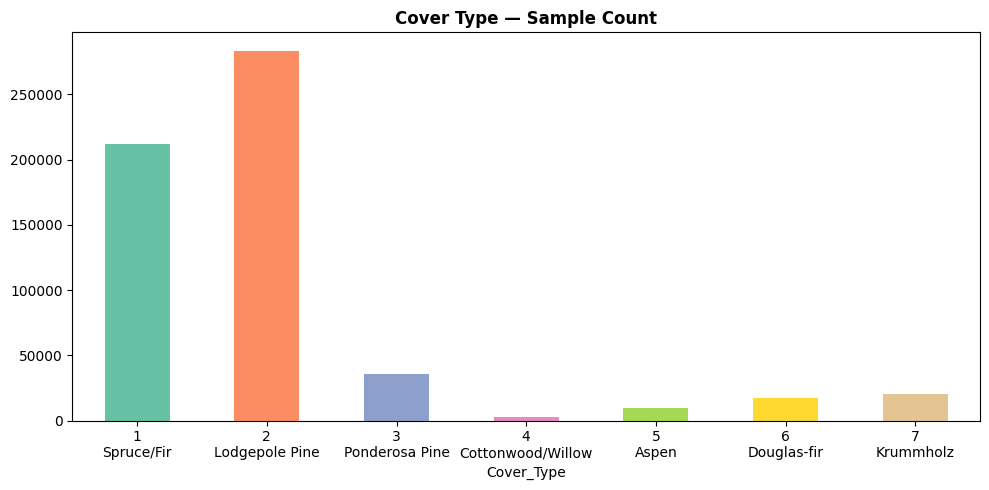

In [48]:
ct_counts = df['Cover_Type'].value_counts().sort_index()
ct_pct    = ct_counts / len(df) * 100
colors    = sns.color_palette('Set2', 7)

ct_counts.plot(kind='bar', color=colors, figsize=(10, 5))
plt.title('Cover Type — Sample Count', fontweight='bold')
plt.xticks(ticks=range(7), labels=[f"{i}\n{COVER_NAMES[i]}" for i in ct_counts.index],rotation=0)
plt.tight_layout()
plt.show()

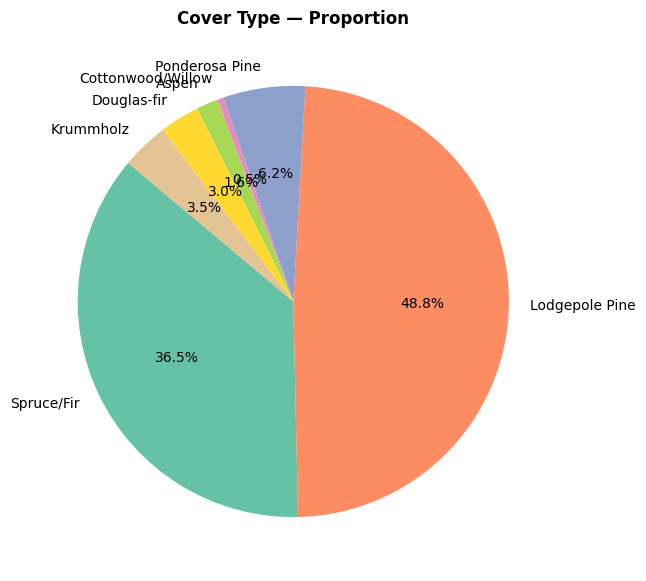

In [49]:
plt.figure(figsize=(7, 7))
plt.pie(ct_counts.values, labels=[COVER_NAMES[i] for i in ct_counts.index],
        autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Cover Type — Proportion', fontweight='bold')
plt.show()

In [50]:
pd.DataFrame({
    'Cover Type'     : ct_counts.index.map(COVER_NAMES),
    'Count'          : ct_counts.values,
    'Percentage (%)' : ct_pct.round(2).values
})

,Cover Type,Count,Percentage (%)
0,Spruce/Fir,211840,36.46
1,Lodgepole Pine,283301,48.76
2,Ponderosa Pine,35754,6.15
3,Cottonwood/Willow,2747,0.47
4,Aspen,9493,1.63
5,Douglas-fir,17367,2.99
6,Krummholz,20510,3.53


### OUTLIER DETECTION WITH IQR 

In [51]:
from scipy.stats import iqr ,norm,uniform
for i , col in enumerate(df_ns):
    Iqr=iqr(df[col])
    lower=np.quantile(df[col],0.25)-1.5*Iqr
    upper=np.quantile(df[col],0.75)+1.5*Iqr
    y = df[(df[col]<lower) | (df[col]>upper)]
    result=(len(y)/581012)*100
    print(f"{i+1}- the outliers in {col} is >>> {len(y)} >> {np.round(result,4)}%")
    print("-"*50)

1- the outliers in Elevation is >>> 14557 >> 2.5055%
--------------------------------------------------
2- the outliers in Aspect is >>> 31463 >> 5.4152%
--------------------------------------------------
3- the outliers in Slope is >>> 669 >> 0.1151%
--------------------------------------------------
4- the outliers in Horizontal_Distance_To_Hydrology is >>> 17433 >> 3.0005%
--------------------------------------------------
5- the outliers in Vertical_Distance_To_Hydrology is >>> 15672 >> 2.6974%
--------------------------------------------------
6- the outliers in Horizontal_Distance_To_Roadways is >>> 7832 >> 1.348%
--------------------------------------------------
7- the outliers in Hillshade_9am is >>> 31157 >> 5.3625%
--------------------------------------------------
8- the outliers in Hillshade_Noon is >>> 0 >> 0.0%
--------------------------------------------------
9- the outliers in Hillshade_3pm is >>> 29884 >> 5.1434%
--------------------------------------------------
10-

## Boxplot To Visualize The Detection oF The Outliers

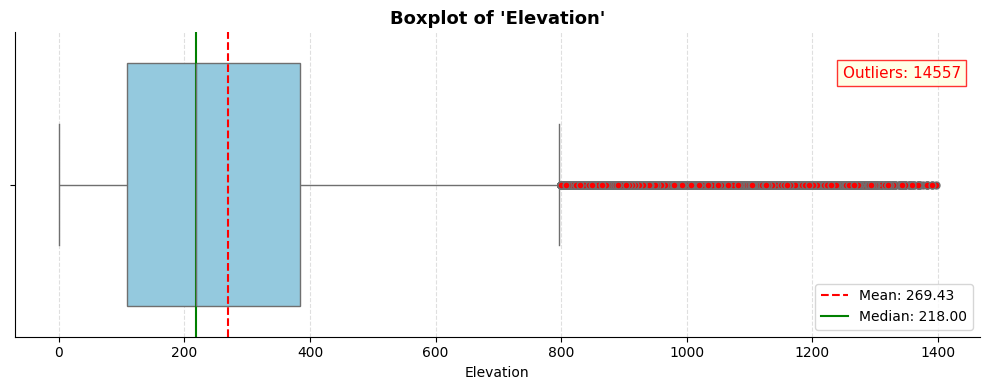

Mean: 269.43 | Median: 218.00 | IQR: 276.00 | Outliers: 14557
--------------------------------------------------


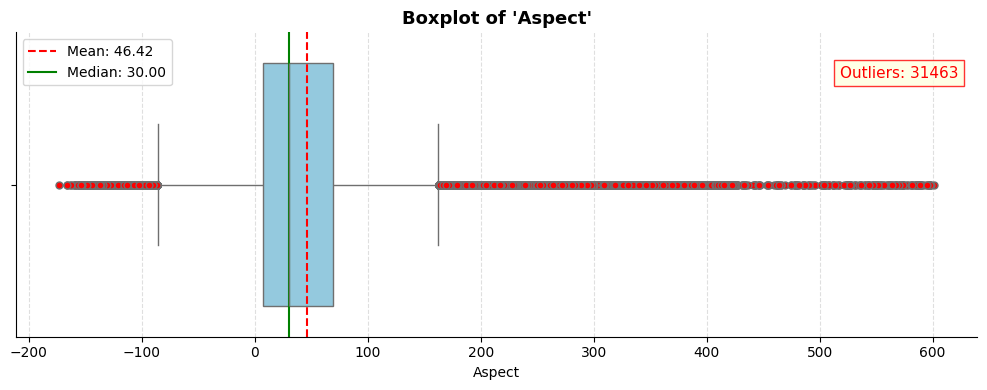

Mean: 46.42 | Median: 30.00 | IQR: 62.00 | Outliers: 31463
--------------------------------------------------


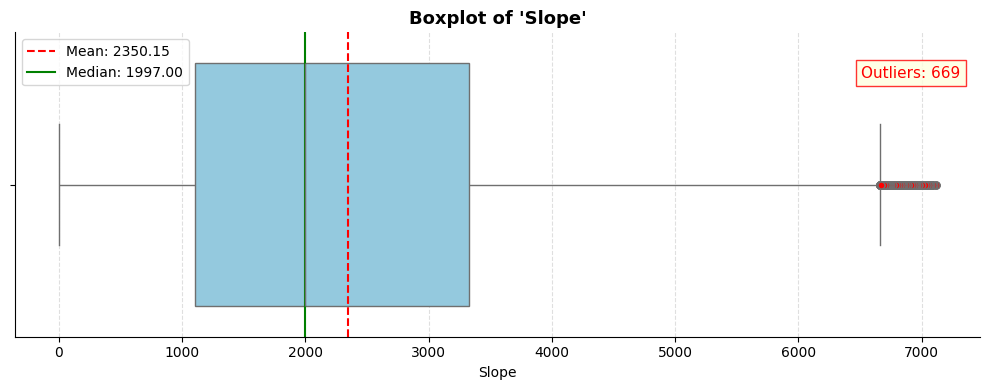

Mean: 2350.15 | Median: 1997.00 | IQR: 2222.00 | Outliers: 669
--------------------------------------------------


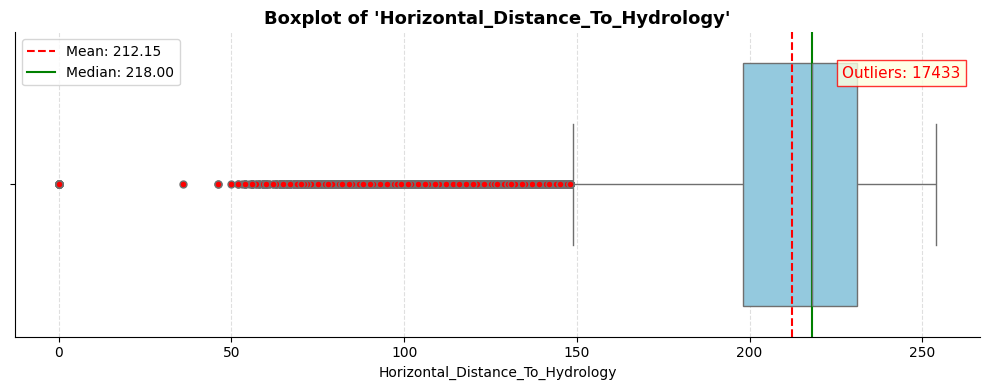

Mean: 212.15 | Median: 218.00 | IQR: 33.00 | Outliers: 17433
--------------------------------------------------


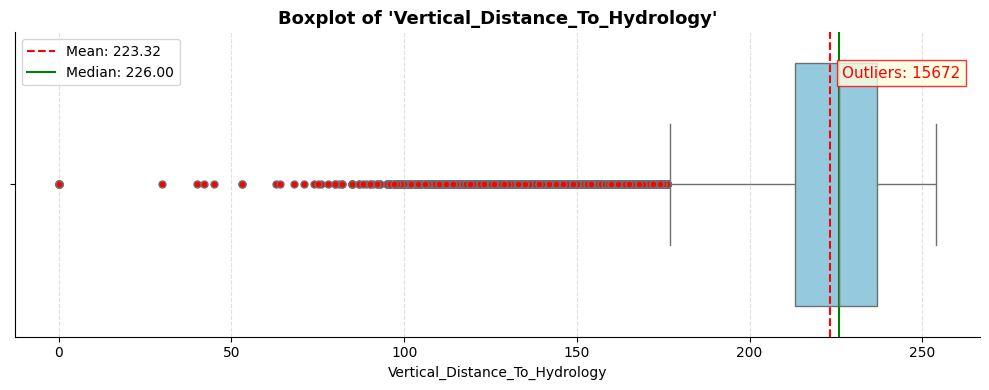

Mean: 223.32 | Median: 226.00 | IQR: 24.00 | Outliers: 15672
--------------------------------------------------


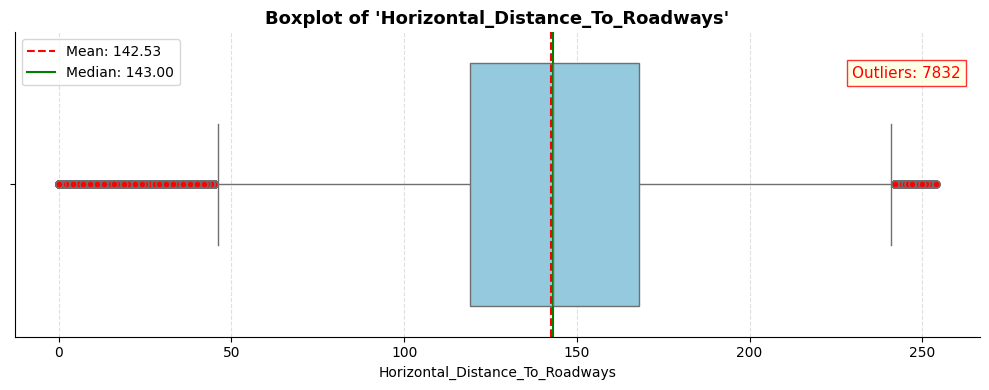

Mean: 142.53 | Median: 143.00 | IQR: 49.00 | Outliers: 7832
--------------------------------------------------


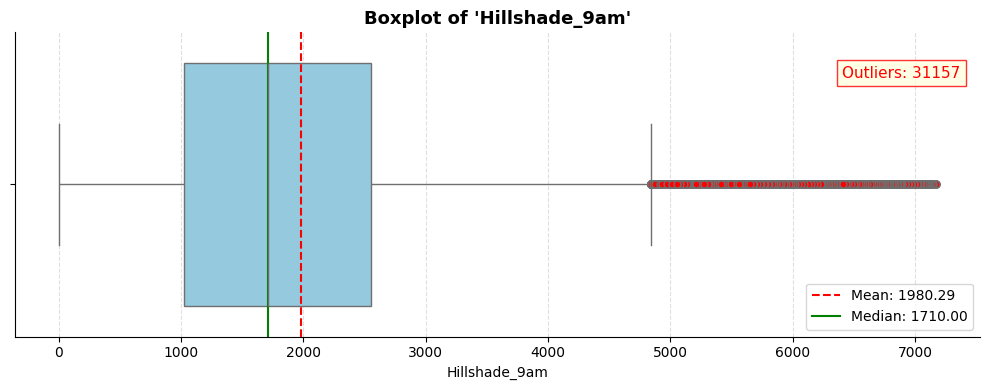

Mean: 1980.29 | Median: 1710.00 | IQR: 1526.00 | Outliers: 31157
--------------------------------------------------


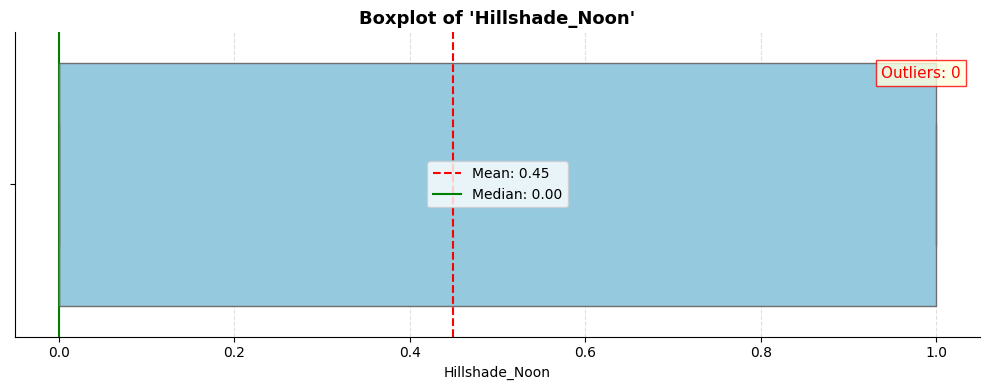

Mean: 0.45 | Median: 0.00 | IQR: 1.00 | Outliers: 0
--------------------------------------------------


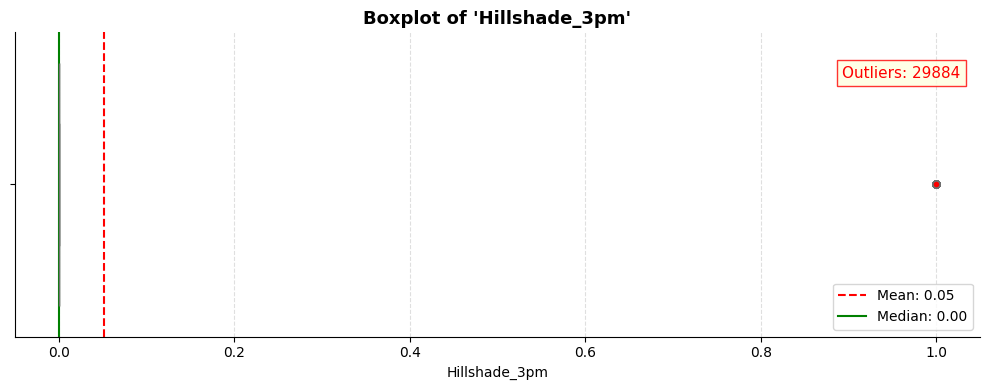

Mean: 0.05 | Median: 0.00 | IQR: 0.00 | Outliers: 29884
--------------------------------------------------


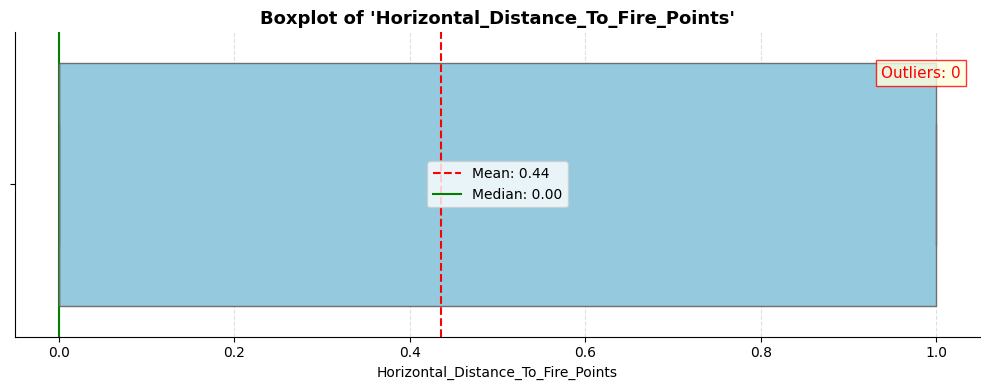

Mean: 0.44 | Median: 0.00 | IQR: 1.00 | Outliers: 0
--------------------------------------------------


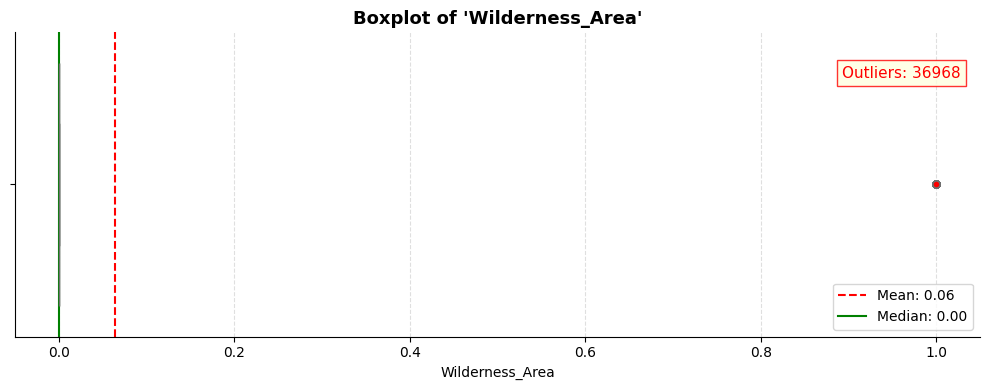

Mean: 0.06 | Median: 0.00 | IQR: 0.00 | Outliers: 36968
--------------------------------------------------


In [52]:
def plot_boxplots(df):
    
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    for col in num_cols:
        Q1     = df[col].quantile(0.25)
        Q3     = df[col].quantile(0.75)
        IQR    = Q3 - Q1
        mean   = df[col].mean()
        median = df[col].median()
        lower  = Q1 - 1.5 * IQR
        upper  = Q3 + 1.5 * IQR
        outliers = len(df[(df[col] < lower) | (df[col] > upper)])
        fig, ax = plt.subplots(figsize=(10, 4))
        
        sns.boxplot(data=df, x=col, ax=ax, color="skyblue",
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=5))

        # Mean and median lines
        ax.axvline(mean,   color="red",   linestyle="--", label=f"Mean: {mean:.2f}")
        ax.axvline(median, color="green", linestyle="-",  label=f"Median: {median:.2f}")

        # Outlier count label
        ax.text(0.98, 0.85, f"Outliers: {outliers}", transform=ax.transAxes,
                ha="right", color="red", fontsize=11,
                bbox=dict(facecolor="lightyellow", edgecolor="red", alpha=0.8))
        ax.set_title(f"Boxplot of '{col}'", fontsize=13, fontweight="bold")
        ax.legend()
        ax.grid(axis="x", linestyle="--", alpha=0.4)
        sns.despine()
        plt.tight_layout()
        plt.show()

        print(f"Mean: {mean:.2f} | Median: {median:.2f} | IQR: {IQR:.2f} | Outliers: {outliers}")
        print("-" * 50)

plot_boxplots(df_ns)

## The Distribution For Each Column

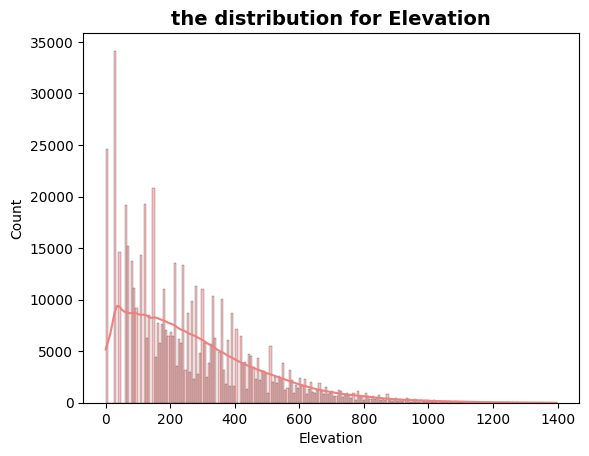

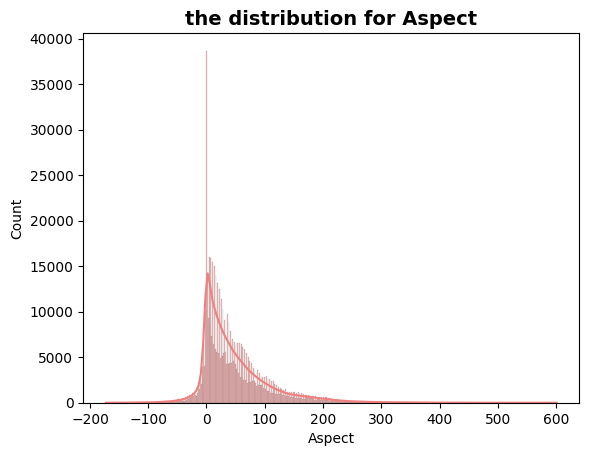

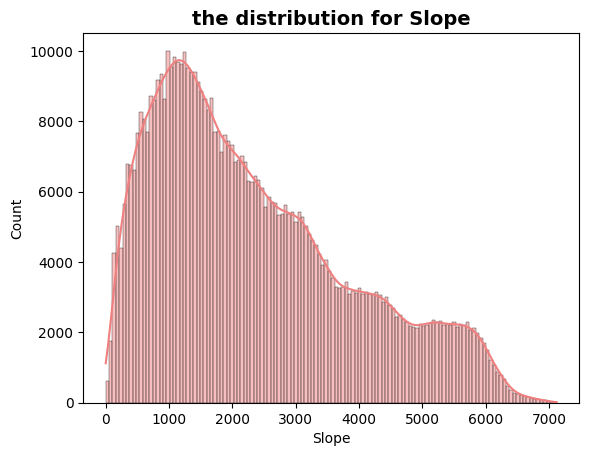

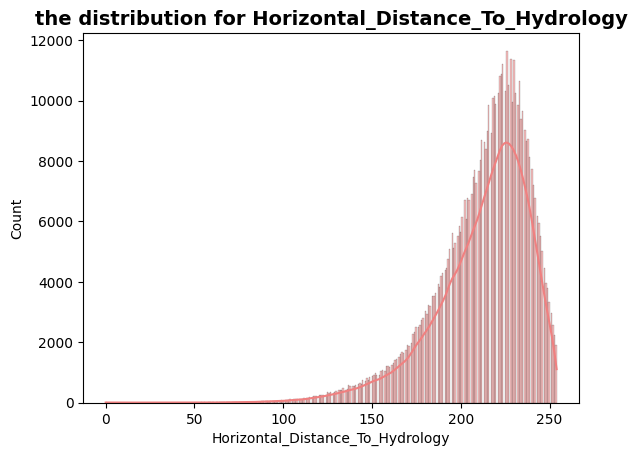

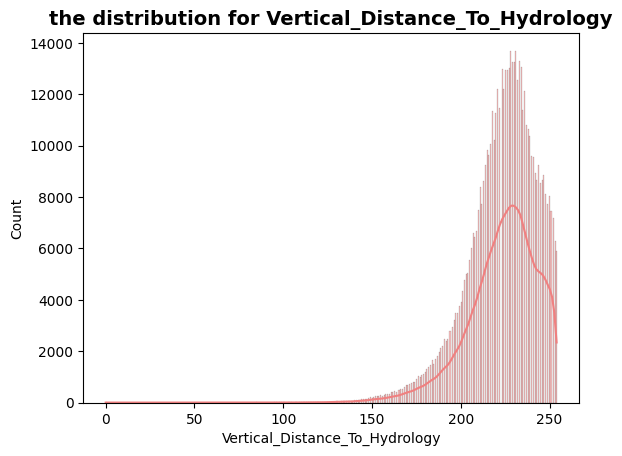

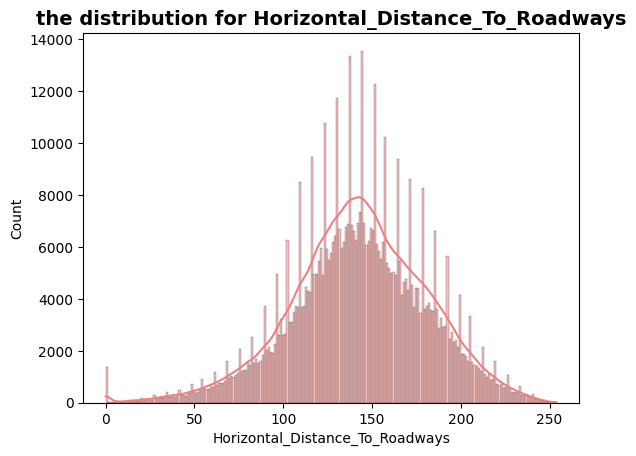

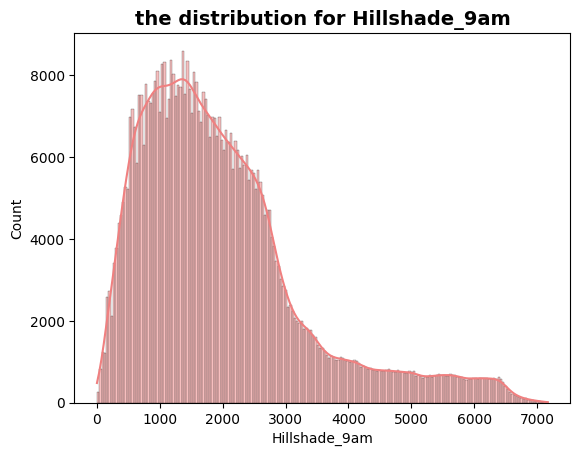

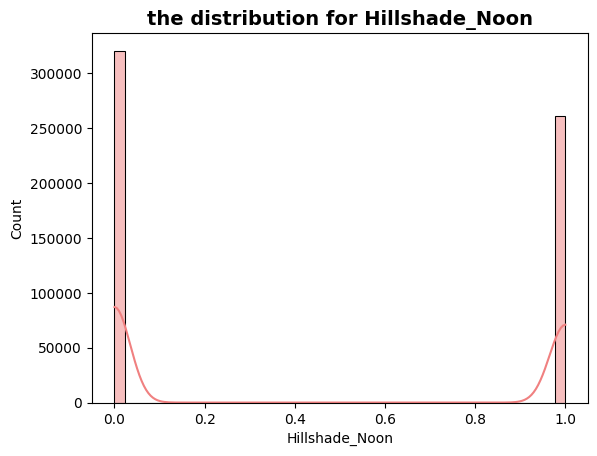

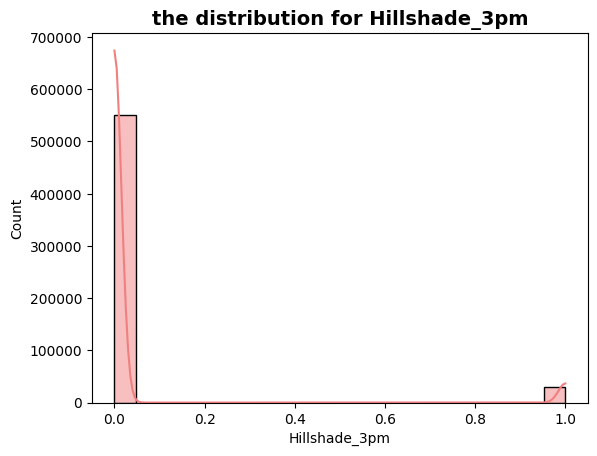

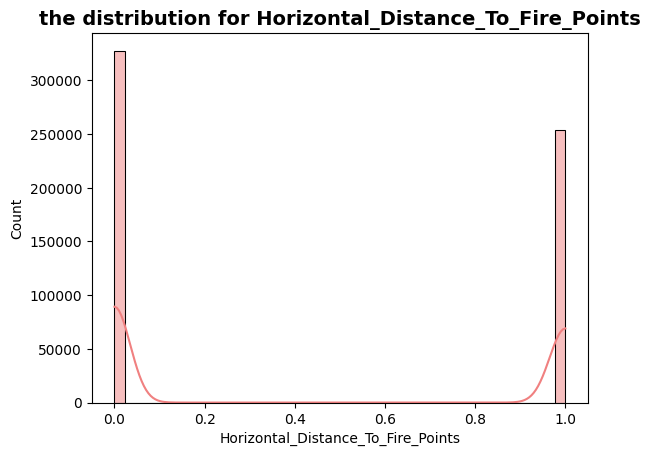

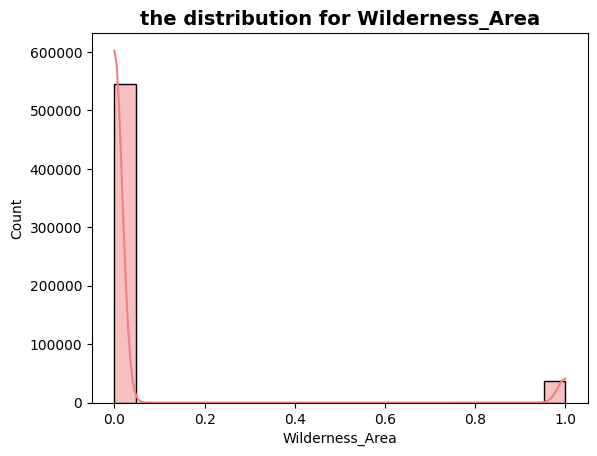

In [53]:
for col in non_soil_cols:
    sns.histplot(df[col], kde=True, color='lightcoral', edgecolor='black')
    plt.title(f"the distribution for {col}",fontsize=14 , fontweight="bold")
    plt.show()

In [54]:
df_ns.skew()

Elevation                             1.140437
Aspect                                1.790250
Slope                                 0.713679
Horizontal_Distance_To_Hydrology     -1.181147
Vertical_Distance_To_Hydrology       -1.063056
Horizontal_Distance_To_Roadways      -0.277053
Hillshade_9am                         1.288644
Hillshade_Noon                        0.205618
Hillshade_3pm                         4.061595
Horizontal_Distance_To_Fire_Points    0.257822
Wilderness_Area                       3.575561
dtype: float64

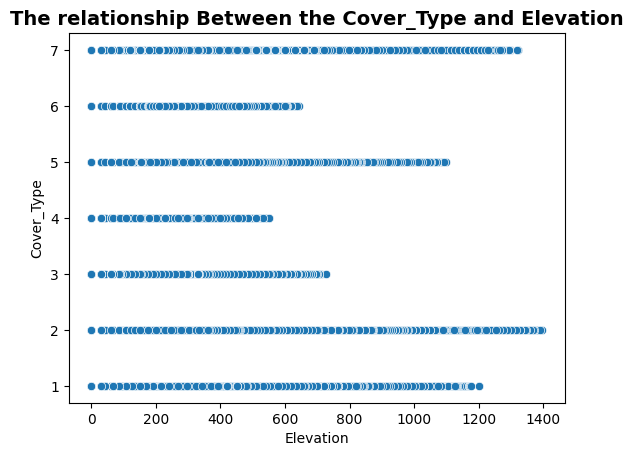

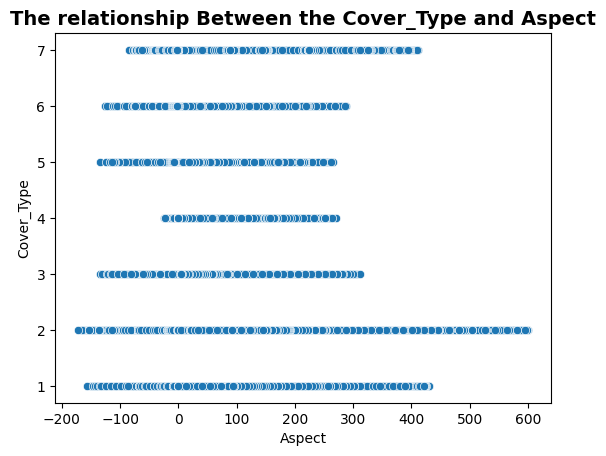

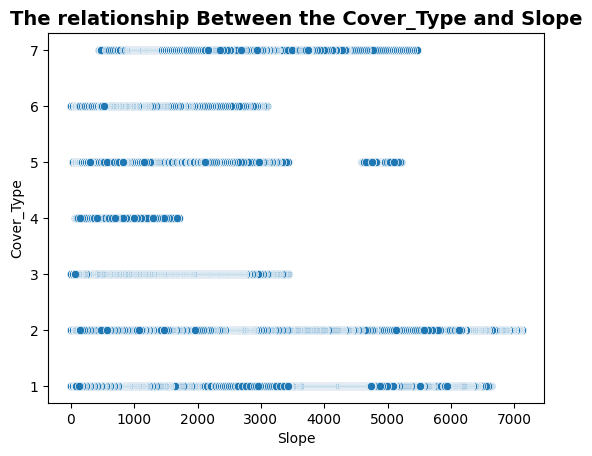

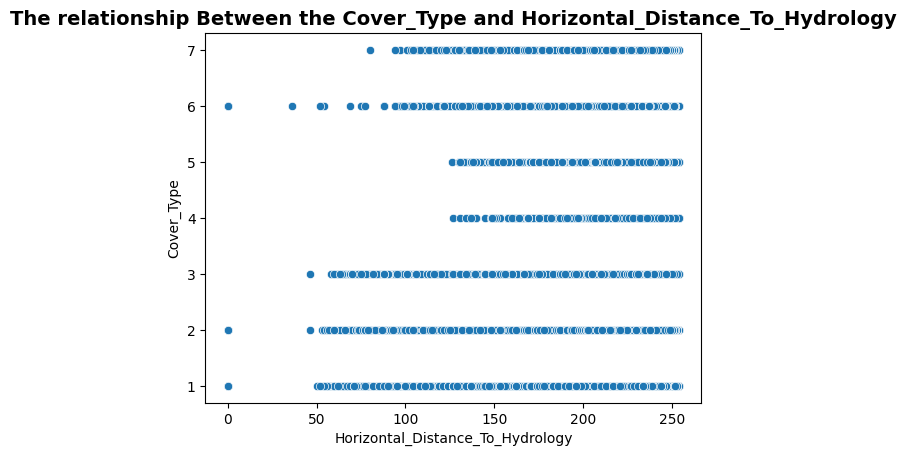

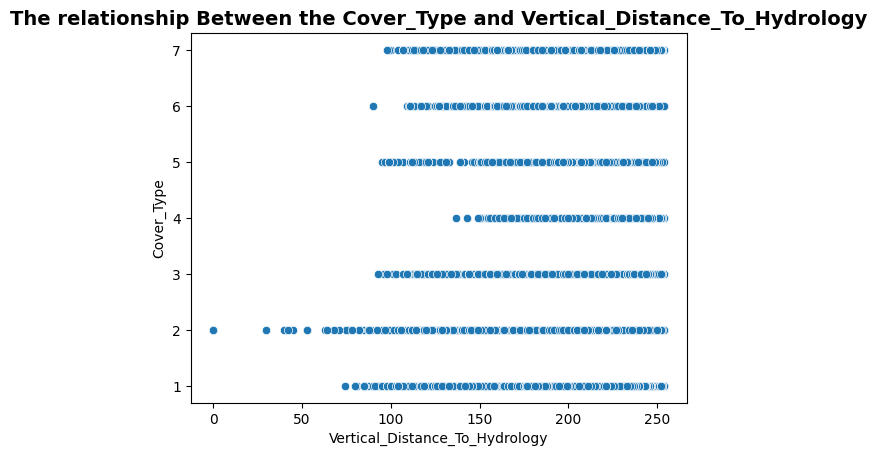

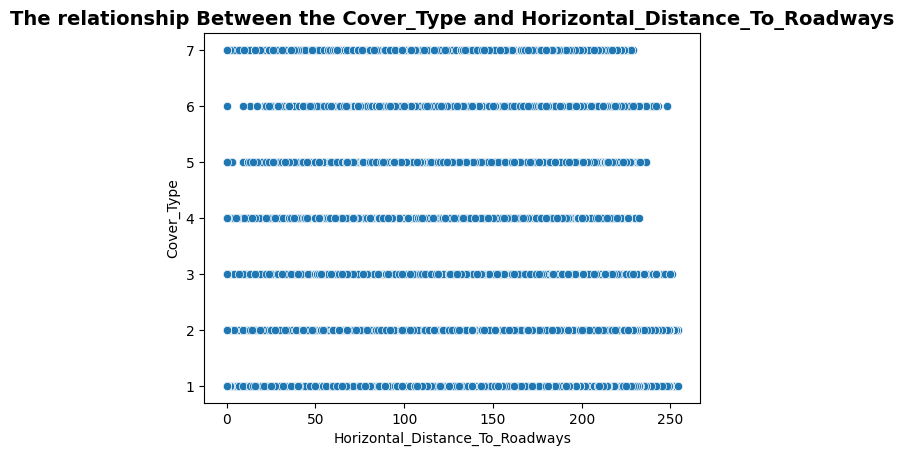

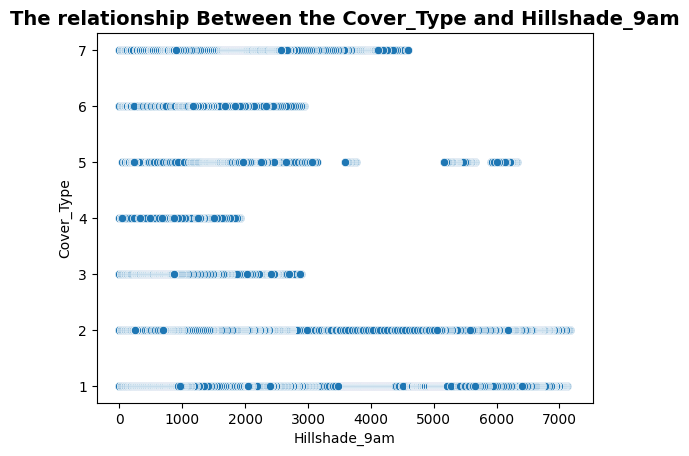

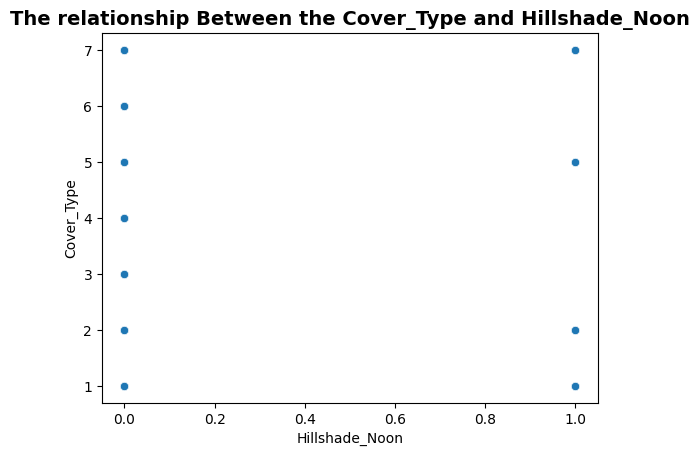

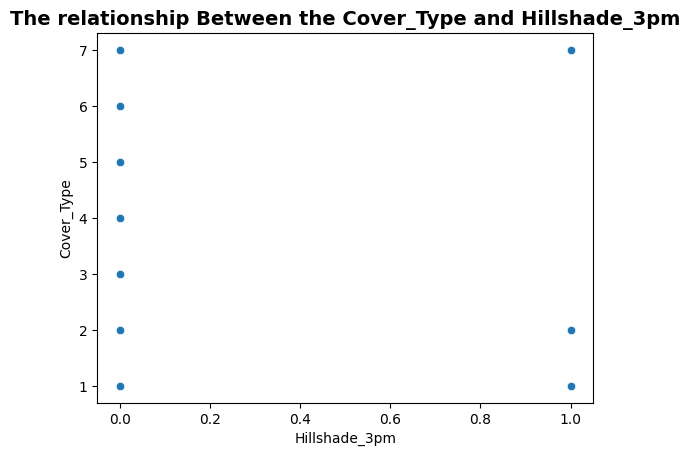

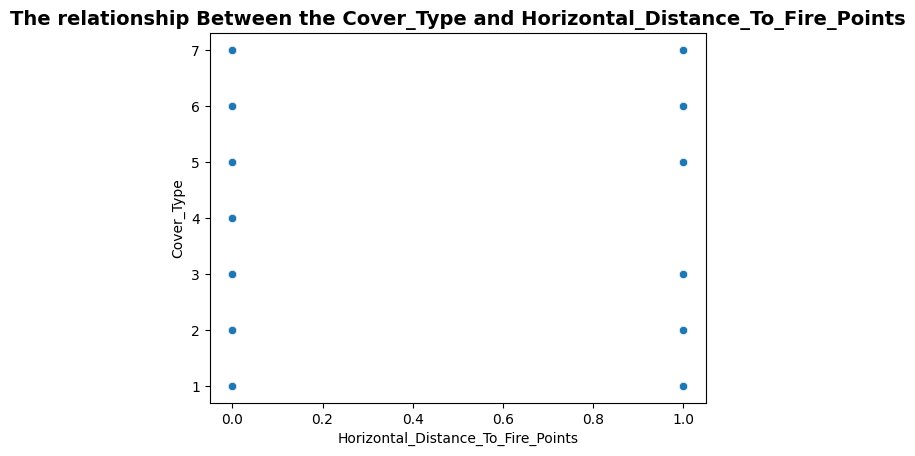

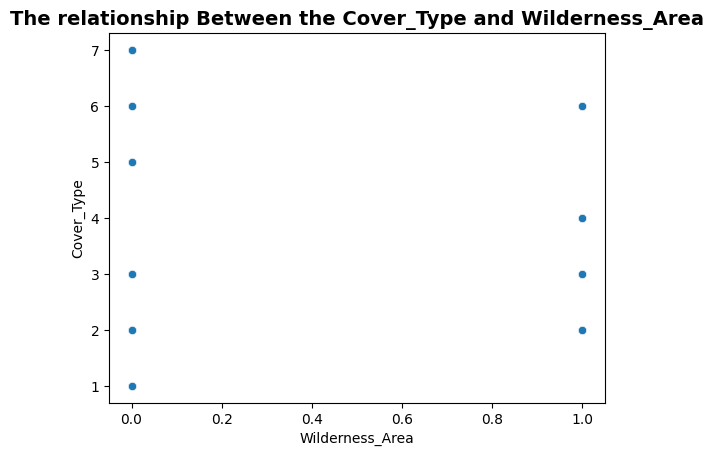

In [55]:
for col in non_soil_cols:
    sns.scatterplot(data=df, x=df[col], y=df["Cover_Type"])
    plt.title(f"The relationship Between the Cover_Type and {col}" , fontsize=14 , fontweight="bold")
    plt.show()

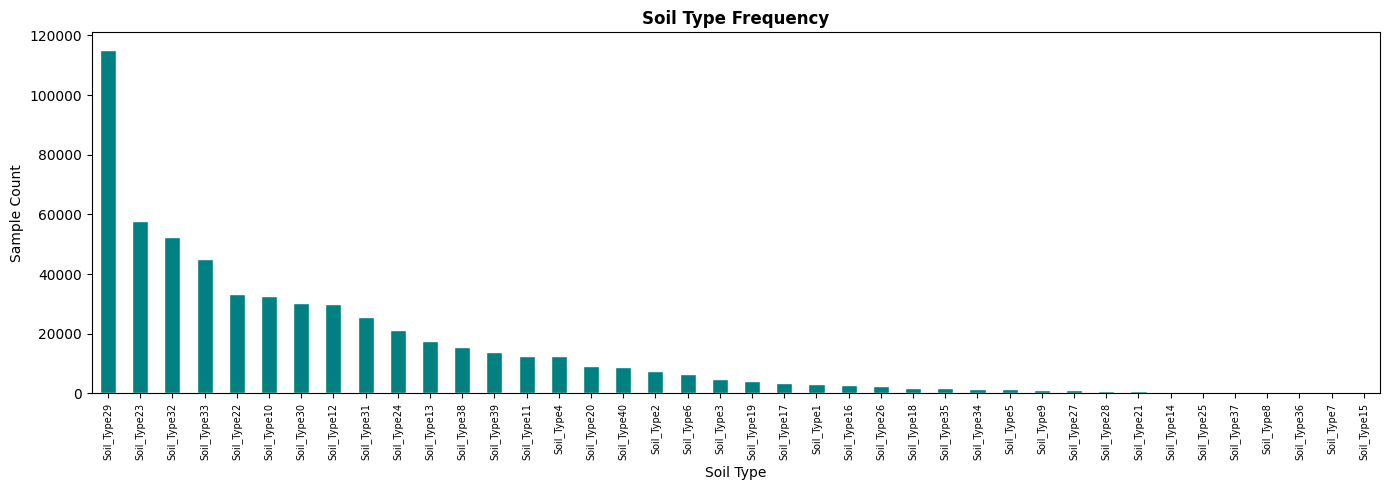

In [56]:
soil_freq = df[soil_features].sum().sort_values(ascending=False)
soil_freq.plot(kind='bar', color='teal', edgecolor='white', figsize=(14, 5))
plt.title('Soil Type Frequency', fontweight='bold')
plt.xlabel('Soil Type')
plt.ylabel('Sample Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [57]:
num_new=['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area','Cover_Type']

df_new=df[num_new]       

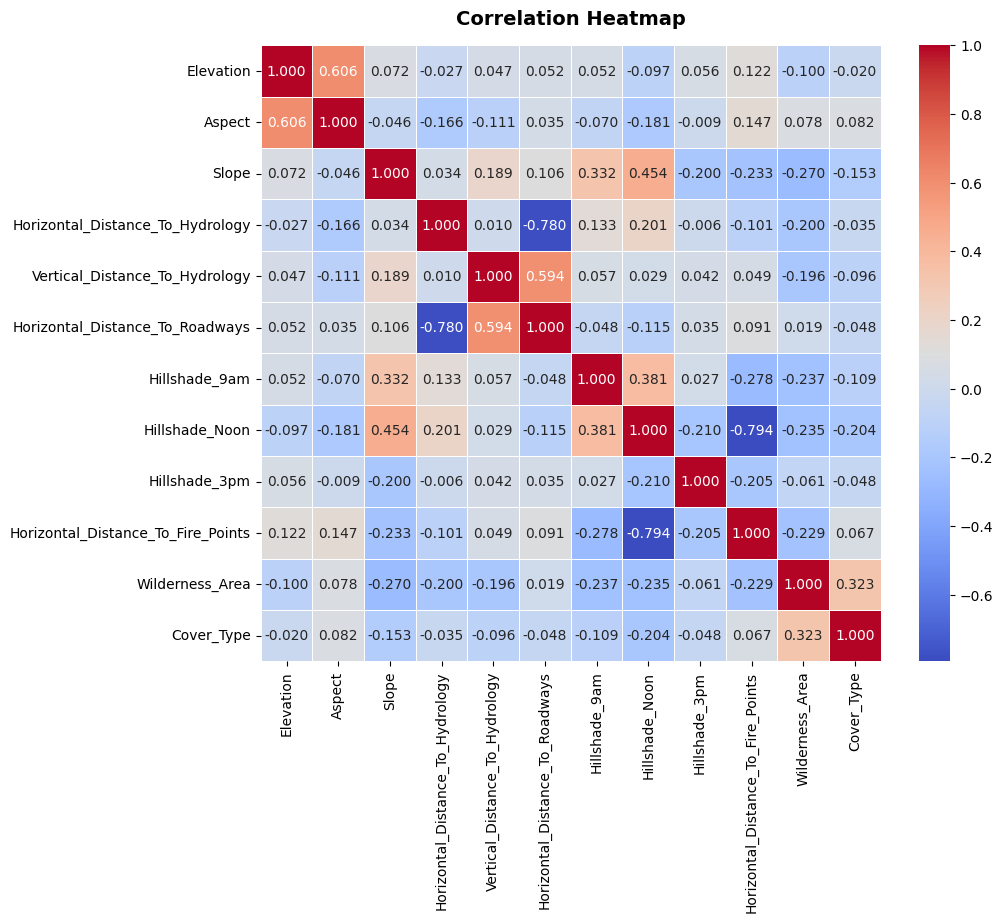

In [58]:
plt.figure(figsize=(10,8))
sns.heatmap(df_new.corr(), annot=True ,cmap="coolwarm" ,linewidths= 0.5,linecolor = "white", fmt= ".3f")
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.show() 

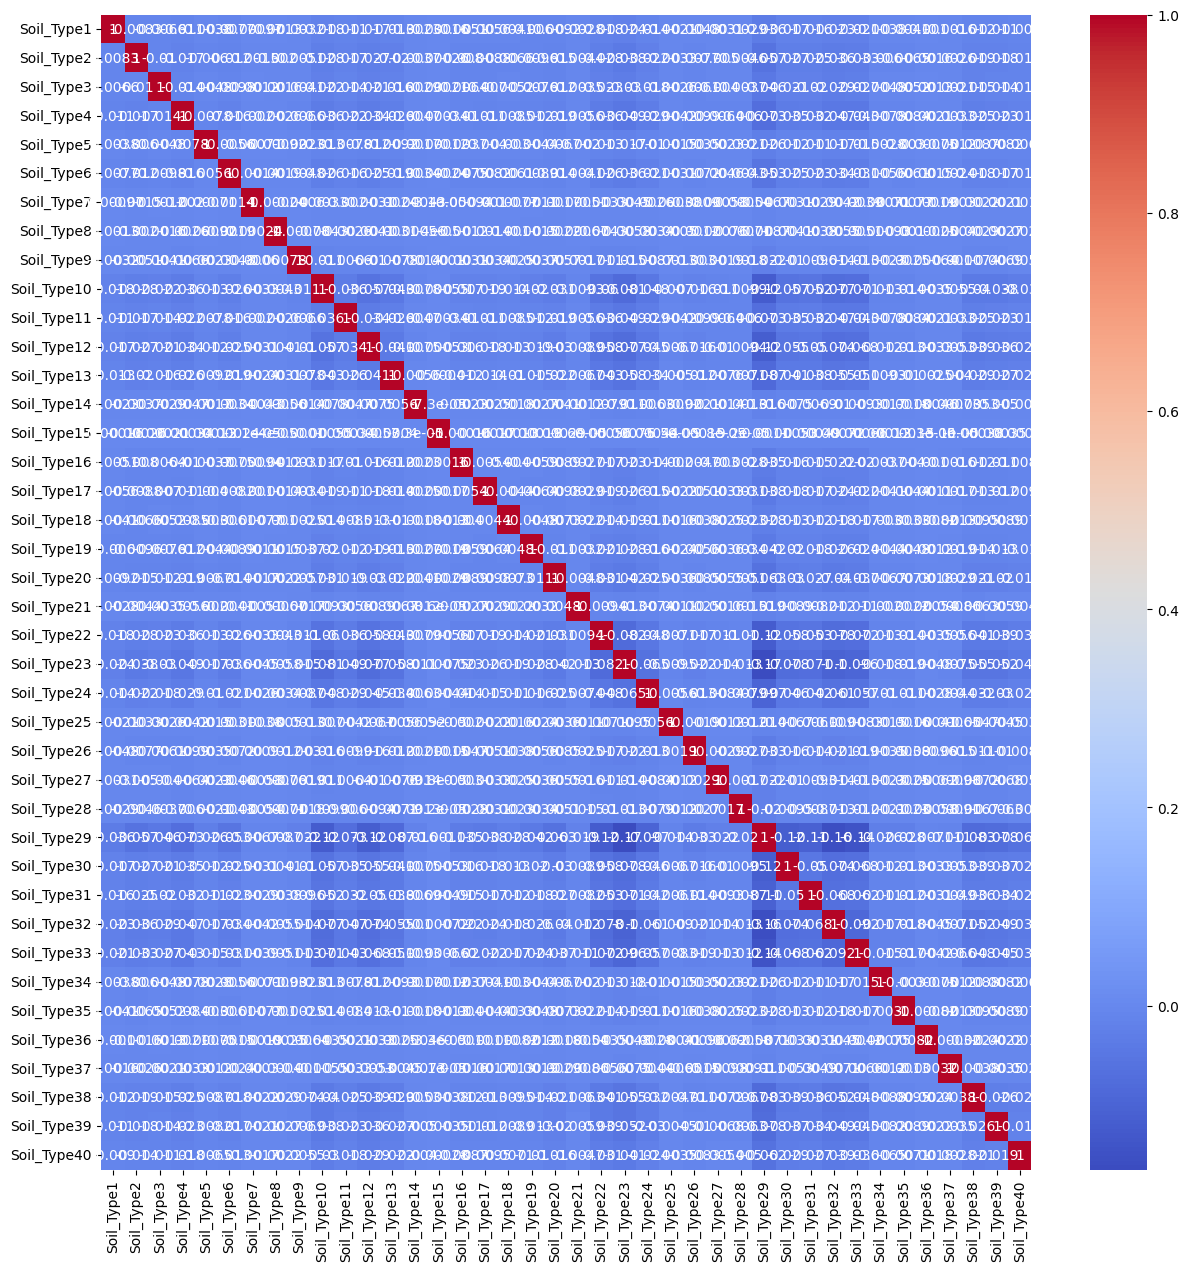

In [59]:
plt.figure(figsize=(15,15))
sns.heatmap(df_s.corr(), annot=True,cmap="coolwarm")
plt.show()

## Scaling By RobustScaler

In [60]:
scaler= RobustScaler()
df_ns_scaled = pd.DataFrame(
    scaler.fit_transform(df_ns),
    columns=non_soil_cols,
    index=df.index
)

In [61]:
df_scaled = pd.concat([df_ns_scaled, df_s], axis=1)
df_scaled['Cover_Type'] = df['Cover_Type']

In [62]:
#from scipy.stats import iqr ,norm,uniform
#for i , col in enumerate(df_scaled):
#   Iqr=iqr(df_scaled[col])
#   lower=np.quantile(df_scaled[col],0.25)-1.5*Iqr
#   upper=np.quantile(df_scaled[col],0.75)+1.5*Iqr
#   y = df_scaled[(df_scaled[col]<lower) | (df_scaled[col]>upper)]
#   result=(len(y)/581012)*100
#   print(f"{i+1}- the outliers in {col} is >>> {len(y)} >> {np.round(result,4)}%")
#   print("-"*50)

In [63]:
df_scaled.columns

Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area', 'Soil_Type1',
       'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6',
       'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11',
       'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15',
       'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19',
       'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23',
       'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27',
       'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31',
       'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35',
       'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39',
       'Soil_Type40', 'Cover_Type'],
      dtype='object')

In [64]:
x=df_scaled.drop("Cover_Type",axis=1)
y=df_scaled["Cover_Type"]

## Spliting The Data

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## RandomForest 

In [75]:
rf = RandomForestClassifier(n_estimators=250, class_weight="balanced",random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
y_pred=rf.predict(X_test)
test_acc_random_forest= accuracy_score(y_test,y_pred)
con_met=confusion_matrix(y_test,y_pred)
class_report=classification_report(y_test,y_pred)
f1_rf  = f1_score(y_test, y_pred, average='macro')
print(f"test accuracy: {(np.round(test_acc_random_forest,4))*100}%")
print(f"test macro F1 score: {(np.round(f1_rf,4))*100}%")
print('━'*60)
print(f"confusion matrix")
print(con_met)
print("-"*70)
print(f"classification report: ")
print(class_report)



test accuracy: 93.89%
test macro F1 score: 90.42999999999999%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
confusion matrix
[[39170  3061    10     0    22     3   102]
 [ 1790 54499   188     3    64    97    20]
 [    4   196  6745    30     5   171     0]
 [    0     8    74   440     0    27     0]
 [   72   367    19     0  1433     8     0]
 [   24   184   293    18     7  2947     0]
 [  173    61     0     0     0     0  3868]]
----------------------------------------------------------------------
classification report: 
              precision    recall  f1-score   support

           1       0.95      0.92      0.94     42368
           2       0.93      0.96      0.95     56661
           3       0.92      0.94      0.93      7151
           4       0.90      0.80      0.85       549
           5       0.94      0.75      0.84      1899
           6       0.91      0.85      0.88      3473
           7       0.97      0.94      0.96      4102

    accuracy   

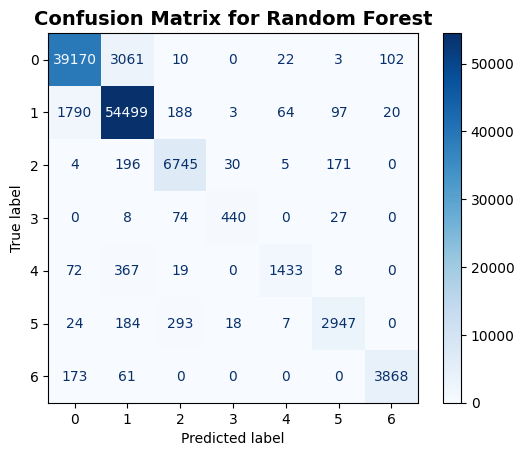

In [ ]:
disp_rf=ConfusionMatrixDisplay(confusion_matrix=con_met)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix for Random Forest", fontsize=14 , fontweight="bold")
plt.show()  

In [68]:
y_train_xgb = y_train - 1
y_test_xgb  = y_test - 1


## XGBOOST

In [69]:

xgbmodel = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    tree_method="hist",
    device="cuda",
    eval_metric="mlogloss",
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "learning_rate":[0.01,0.05,0.1,0.2,0.5],
    "max_depth": [2,3,4,5,6,7,8],
    "subsample":[0.6,0.7,0.8,0.9,1],
    "colsample_bytree":[0.6,0.7,0.8,0.9,1],
    "reg_alpha":[0,0.1,0.3,0.5,0.7,1],    
    "reg_lambda":[0,0.1,0.3,0.5,0.7,1],
    "gamma":[0,0.1,0.3,0.5,0.7,1]
}

random_search = RandomizedSearchCV(
    estimator=xgbmodel,
    param_distributions=param_dist,
    n_iter=30,
    cv=4,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(
    X_train,
    y_train_xgb
    
)

best_model = random_search.best_estimator_

y_pred_xgb= best_model.predict(X_test)


Fitting 4 folds for each of 30 candidates, totalling 120 fits


c:\Users\mohan\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [01:28:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


In [76]:
f1_xgb = f1_score(y_test_xgb, y_pred_xgb, average='macro')
test_acc_xgb= accuracy_score(y_test_xgb,y_pred_xgb)
con_met_xgb=confusion_matrix(y_test_xgb,y_pred_xgb)
class_report_xgb=classification_report(y_test_xgb,y_pred_xgb)
print(f"Test accuracy: {(np.round(test_acc_xgb, 4))*100}%")
print(f"Test macro F1 score: {(np.round(f1_xgb,4))*100}%")
print('━'*70)
print("Best params:", random_search.best_params_)
print("-"*70)
print("Confusion matrix:")
print(con_met_xgb)
print("-"*70)
print("Classification report:")
print(class_report_xgb)



Test accuracy: 88.01%
Test macro F1 score: 87.82%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Best params: {'subsample': 0.8, 'reg_lambda': 0.7, 'reg_alpha': 1, 'max_depth': 6, 'learning_rate': 0.5, 'gamma': 0.3, 'colsample_bytree': 0.9}
----------------------------------------------------------------------
Confusion matrix:
[[35207  6946     6     0    37    18   154]
 [ 4364 51697   249     3   156   170    22]
 [    5   216  6637    37     9   247     0]
 [    0    10    55   458     0    26     0]
 [   55   353    22     0  1458    11     0]
 [   27   186   290    19    15  2936     0]
 [  149    75     0     0     1     0  3877]]
----------------------------------------------------------------------
Classification report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86     42368
           1       0.87      0.91      0.89     56661
           2       0.91      0.93      0.92      7151
           3       

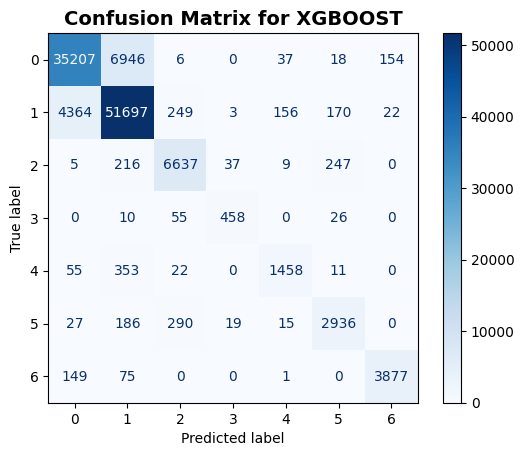

In [71]:
disp_rf=ConfusionMatrixDisplay(confusion_matrix=con_met_xgb)
disp_rf.plot(cmap="Blues")
plt.title("Confusion Matrix for XGBOOST", fontsize=14 , fontweight="bold")
plt.show()  

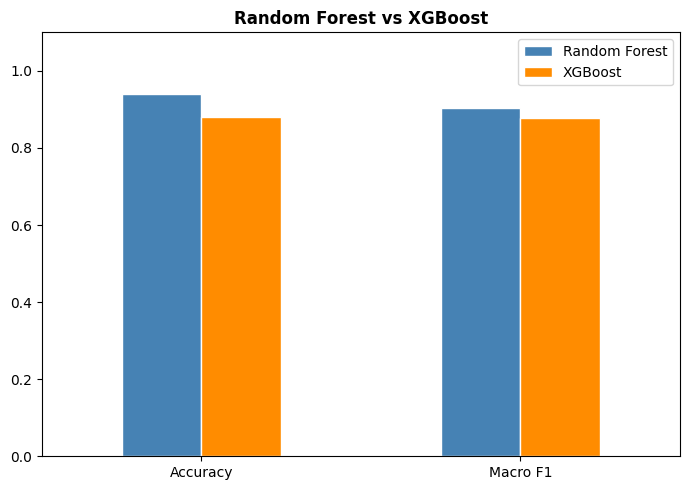

In [77]:
scores = pd.DataFrame({
    'Random Forest': [test_acc_random_forest, f1_rf],
    'XGBoost'      : [test_acc_xgb, f1_xgb]
}, index=['Accuracy', 'Macro F1'])

scores.plot(kind='bar', color=['steelblue', 'darkorange'], edgecolor='white', figsize=(7, 5))
plt.title('Random Forest vs XGBoost', fontweight='bold')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()